# Bike Rental Forecasting

## Goal

---

The goal of this notebook is to develop and evaluate forecasting models for bike rental demand using the curated dataset produced by the preprocessing pipeline.

Starting from simple baseline models, a series of feature engineering techniques and machine learning algorithms are explored and compared. Particular emphasis is placed on capturing the temporal patterns, seasonality, and recurring demand behavior identified during the exploratory data analysis.

All experiments are evaluated using a consistent train-test split and the same evaluation metrics to ensure fair comparison between approaches. This enables the impact of individual feature engineering techniques and model choices to be assessed systematically.

The notebook progresses from baseline models to increasingly sophisticated feature sets and machine learning algorithms, culminating in a comparison of the strongest-performing approaches. The best-performing model and feature set will serve as the candidate for later integration into the Dagster pipeline.


## 1. Load Dataset

---

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("../../data/processed/bike_rental_features.csv")

df.head()

,datetime_hour,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,hour,weekday,month,is_weekend,is_holiday,booked_rentals,direct_pickups,total_rentals
0,2011-01-01 00:00:00,clear,3.3,3.0,81.0,0.0,0,5,1,True,False,13,3,16
1,2011-01-01 01:00:00,clear,2.3,2.0,80.0,0.0,1,5,1,True,False,32,8,40
2,2011-01-01 02:00:00,clear,2.3,2.0,80.0,0.0,2,5,1,True,False,27,5,32
3,2011-01-01 03:00:00,clear,3.3,3.0,75.0,0.0,3,5,1,True,False,10,3,13
4,2011-01-01 04:00:00,clear,3.3,3.0,75.0,0.0,4,5,1,True,False,1,0,1


## 2. Helper Functions & Constants

---


In [2]:
TARGET = "total_rentals"

TRAIN_RATIO = 0.8

BASELINE_RESULTS = {
    "MAE": 134.30,
    "RMSE": 199.58,
    "R2": 0.18,
}

BASE_FEATURES = [
    "temperature_c",
    "perceived_temperature_c",
    "humidity",
    "windspeed_kmh",
    "weekday",
    "is_weekend",
    "is_holiday",
    "conditions_clouds",
    "conditions_heavy_rain",
    "conditions_light_rain",
]

BASELINE_FEATURES = BASE_FEATURES + [
    "hour",
    "month",
]

CYCLICAL_FEATURES = BASE_FEATURES + [
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
]

LAG_24H_FEATURES = CYCLICAL_FEATURES + [
    "lag_24h",
]

LAG_24H_168H_FEATURES = CYCLICAL_FEATURES + [
    "lag_24h",
    "lag_168h",
]

ROLLING_FEATURES = LAG_24H_168H_FEATURES + [
    "rolling_mean_24h",
    "rolling_mean_168h",
]

In [3]:
def temporal_train_test_split(
    X,
    y,
    train_ratio=TRAIN_RATIO,
):
    """Split features and targets into chronological training and test sets."""
    split_idx = int(len(X) * train_ratio)

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    return X_train, X_test, y_train, y_test

In [4]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)


def evaluate_regression_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
):
    """Calculate regression metrics for a trained model's predictions."""
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    return {
        "MAE": mean_absolute_error(
            y_test,
            predictions,
        ),
        "RMSE": root_mean_squared_error(
            y_test,
            predictions,
        ),
        "R2": r2_score(
            y_test,
            predictions,
        ),
    }

In [5]:
def run_experiment(
    model,
    X,
    y,
    model_name,
    return_model=False,
):
    """Train, evaluate, and record the results of a forecasting experiment."""
    X_train, X_test, y_train, y_test = temporal_train_test_split(
        X,
        y,
        train_ratio=TRAIN_RATIO,
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    results = {
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": root_mean_squared_error(y_test, predictions),
        "R2": r2_score(y_test, predictions),
    }

    if return_model:
        return results, model, X_train.columns

    return results

In [6]:
# Experiment Tracking

experiment_results = []

## 3. Baseline Models

---

Before evaluating additional feature engineering techniques and more advanced machine learning models, a baseline must be established.

The purpose of the baseline is to provide a reference point against which all subsequent experiments can be compared. Two baseline models are considered:

- A Dummy Regressor, which predicts the average rental demand for all observations.
- A Linear Regression model using the original weather and temporal features.

These models provide an initial assessment of the predictive value contained in the dataset and establish the minimum performance that future experiments should exceed.

Any feature engineering techniques or alternative models introduced in the following sections should improve upon these baseline metrics to justify their additional complexity.

In [7]:
df = pd.get_dummies(
    df,
    columns=["conditions"],
    drop_first=True,
)

X = df[BASELINE_FEATURES]
y = df[TARGET]

In [8]:
from sklearn.dummy import DummyRegressor

experiment_results.append(
    run_experiment(
        model=DummyRegressor(strategy="mean"),
        X=df[BASELINE_FEATURES],
        y=df[TARGET],
        model_name="Dummy Regressor",
    )
)

In [9]:
from sklearn.linear_model import LinearRegression

experiment_results.append(
    run_experiment(
        model=LinearRegression(),
        X=df[BASELINE_FEATURES],
        y=df[TARGET],
        model_name="Linear Regression (Baseline)",
    )
)

pd.DataFrame(experiment_results)

,Model,MAE,RMSE,R2
0,Dummy Regressor,174.984601,232.608375,-0.112995
1,Linear Regression (Baseline),134.299475,199.577420,0.180658


## 4. Experiment 1 - Cyclical Time Features

---

### Motivation

The baseline model represents the `hour` and `month` features as linear numerical values. However, both variables are cyclical in nature. For example, 23:00 and 00:00 are only one hour apart, while December and January represent consecutive months despite having numerically distant values.

Linear Regression cannot inherently capture these circular relationships when using the raw feature values. To address this limitation, the `hour` and `month` features are transformed using sine and cosine functions. This encoding preserves their cyclical structure while remaining compatible with linear models.

The resulting model is evaluated against the baseline Linear Regression model to determine whether a more appropriate representation of temporal information improves forecasting performance.

In [10]:
import numpy as np

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)

df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)

df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [11]:
X = df[CYCLICAL_FEATURES]
y = df[TARGET]

experiment_results.append(
    run_experiment(
        model=LinearRegression(),
        X=df[CYCLICAL_FEATURES],
        y=df[TARGET],
        model_name="Linear Regression + Cyclical Features",
    )
)

pd.DataFrame(experiment_results)

,Model,MAE,RMSE,R2
0,Dummy Regressor,174.984601,232.608375,-0.112995
1,Linear Regression (Baseline),134.299475,199.577420,0.180658
2,Linear Regression + Cyclical Features,121.484463,189.591262,0.260600


#### Observations

* Replacing the linear hour and month features with cyclical encodings improved performance across all evaluation metrics.

* The MAE decreased from 134.3 to 121.5 rentals, indicating that the model's average prediction error was reduced by approximately 13 rentals per hour.

* The RMSE decreased from 199.6 to 189.6 rentals, demonstrating an improvement in the model's ability to handle larger prediction errors.

* The R² score increased from 0.18 to 0.26, meaning that the model is able to explain a substantially larger portion of the variability in rental demand.

* The results suggest that representing time as a cyclical concept better reflects the underlying structure of the problem than using raw hour and month values.

* This experiment demonstrates that feature engineering alone can significantly improve model performance without increasing model complexity.

### Conclusion

The cyclical encoding of temporal features produced a clear improvement over the baseline Linear Regression model. Given the strong daily and seasonal patterns identified during the exploratory analysis, this result is consistent with expectations and confirms that an appropriate representation of time is important for forecasting bike rental demand.

The cyclical feature set will therefore be used as the foundation for subsequent experiments.

## 5. Experiment 2 - Lag Features

### Motivation

The exploratory data analysis revealed strong temporal structure in the bike rental demand series, including daily patterns, weekly seasonality, and long-term trends. However, the previous models only relied on weather and calendar information and had no knowledge of historical rental demand.

Lag features provide the model with information about past demand levels by incorporating rental counts from previous time periods as predictors. This allows the model to leverage temporal dependencies that are common in forecasting problems.

The effectiveness of lag features will be evaluated by comparing the resulting model against the best-performing model from the previous experiment.

In [12]:
df["lag_24h"] = df["total_rentals"].shift(24)

df_lag = df.dropna().copy()

In [13]:
experiment_results.append(
    run_experiment(
        model=LinearRegression(),
        X=df_lag[LAG_24H_FEATURES],
        y=df_lag[TARGET],
        model_name="Linear Regression + Lag 24h",
    )
)

pd.DataFrame(experiment_results)

,Model,MAE,RMSE,R2
0,Dummy Regressor,174.984601,232.608375,-0.112995
1,Linear Regression (Baseline),134.299475,199.577420,0.180658
2,Linear Regression + Cyclical Features,121.484463,189.591262,0.260600
3,Linear Regression + Lag 24h,78.640753,122.810077,0.690118


In [14]:
df["lag_168h"] = df["total_rentals"].shift(168)

df_lag = df.dropna().copy()

In [15]:
experiment_results.append(
    run_experiment(
        model=LinearRegression(),
        X=df_lag[LAG_24H_168H_FEATURES],
        y=df_lag[TARGET],
        model_name="Linear Regression + Lag 168h",
    )
)

pd.DataFrame(experiment_results)

,Model,MAE,RMSE,R2
0,Dummy Regressor,174.984601,232.608375,-0.112995
1,Linear Regression (Baseline),134.299475,199.577420,0.180658
2,Linear Regression + Cyclical Features,121.484463,189.591262,0.260600
3,Linear Regression + Lag 24h,78.640753,122.810077,0.690118
4,Linear Regression + Lag 168h,66.953963,103.486786,0.778388


#### Observations

* Adding historical demand information resulted in a substantial improvement over both the baseline model and the cyclical feature model.

* The introduction of the 24-hour lag feature reduced the MAE from 121.5 to 78.6 rentals and increased the R² score from 0.26 to 0.69. This indicates that demand at the same time on the previous day is highly informative for forecasting future rental activity.

* Incorporating the additional 168-hour lag feature further improved performance across all evaluation metrics. The R² score increased to 0.78 while the RMSE decreased to 103.5 rentals.

* The strong performance gains confirm that bike rental demand exhibits significant temporal dependencies and recurring daily and weekly patterns.

* Compared to the improvements achieved through cyclical encoding alone, lag features provide substantially more predictive information, suggesting that historical demand is one of the most important drivers of future demand.

### Conclusion

The lag feature experiments produced the largest improvement observed so far. While cyclical time features helped the model better represent recurring temporal patterns, historical demand information proved to be considerably more valuable.

The results indicate that bike rental demand is strongly influenced by previous demand levels, particularly demand from the same hour on the previous day and the previous week. This finding is consistent with the temporal patterns and seasonality identified during the exploratory data analysis.

Given the magnitude of the improvement, lag features should be retained in subsequent experiments and can be considered a key component of future forecasting models.

Lag features were generated using row-based shifts on the chronologically ordered dataset. Due to a small number of missing timestamps in the source data, some lag values may not correspond exactly to the intended hourly offset. This simplification was considered acceptable for the purpose of model experimentation and may be revisited in a future production implementation.

## 6. Experiment 3 - Rolling Statistics

---

### Motivation

The previous experiment demonstrated that historical demand information is highly predictive of future rental activity. However, lag features only provide information from individual past observations.

Historical demand aggregations summarize multiple previous observations and may therefore capture recurring demand patterns more robustly than individual lag values. In particular, aggregations based on similar temporal contexts, such as the same hour of day or the same weekday and hour combination, may better reflect the regular usage patterns identified during the exploratory analysis.

This experiment evaluates several historical demand aggregation strategies and compares their effectiveness against the lag-based model.


### 6.1 Generic Rolling Means

In [16]:
df["rolling_mean_24h"] = df["total_rentals"].shift(1).rolling(24).mean()

df["rolling_mean_168h"] = df["total_rentals"].shift(1).rolling(168).mean()

df_rolling = df.dropna().copy()

In [17]:
experiment_results.append(
    run_experiment(
        model=LinearRegression(),
        X=df_rolling[ROLLING_FEATURES],
        y=df_rolling[TARGET],
        model_name="Linear Regression + Generic Rolling Means",
    )
)

pd.DataFrame(experiment_results)

,Model,MAE,RMSE,R2
0,Dummy Regressor,174.984601,232.608375,-0.112995
1,Linear Regression (Baseline),134.299475,199.577420,0.180658
2,Linear Regression + Cyclical Features,121.484463,189.591262,0.260600
3,Linear Regression + Lag 24h,78.640753,122.810077,0.690118
4,Linear Regression + Lag 168h,66.953963,103.486786,0.778388
5,Linear Regression + Generic Rolling Means,66.845043,102.597320,0.782181


#### Observations

* Generic rolling averages produced only minor improvements over the lag-based model.

* The limited performance gain suggests that the lag features already capture most of the useful information contained in recent demand history.

* Averaging across all hours may obscure important temporal patterns by combining observations from different times of day and days of the week.

### 6.2 Same-Hour Historical Average

In [18]:
df["same_hour_mean_7d"] = df.groupby("hour")["total_rentals"].transform(
    lambda s: (
        s.shift(1)
        .rolling(
            window=7,
            min_periods=1,
        )
        .mean()
    )
)

In [19]:
df_contextual_rolling = df.dropna().copy()

CONTEXTUAL_ROLLING_FEATURE = ROLLING_FEATURES + [
    "same_hour_mean_7d",
]

experiment_results.append(
    run_experiment(
        model=LinearRegression(),
        X=df_contextual_rolling[CONTEXTUAL_ROLLING_FEATURE],
        y=df_contextual_rolling[TARGET],
        model_name="Linear Regression + Same-Hour Mean 7d",
    )
)

pd.DataFrame(experiment_results)

,Model,MAE,RMSE,R2
0,Dummy Regressor,174.984601,232.608375,-0.112995
1,Linear Regression (Baseline),134.299475,199.577420,0.180658
2,Linear Regression + Cyclical Features,121.484463,189.591262,0.260600
3,Linear Regression + Lag 24h,78.640753,122.810077,0.690118
4,Linear Regression + Lag 168h,66.953963,103.486786,0.778388
5,Linear Regression + Generic Rolling Means,66.845043,102.597320,0.782181
6,Linear Regression + Same-Hour Mean 7d,66.166453,97.259968,0.804255


#### Observations

* Restricting the aggregation to observations from the same hour produced a larger improvement than the generic rolling averages.

* This result indicates that demand patterns are strongly tied to the time of day and that aggregating similar hourly observations provides more useful information than averaging across all recent demand.

### 6.3 Same Weekday and Hour Historical Average

In [20]:
df["same_weekday_hour_mean_4w"] = df.groupby(["weekday", "hour"])["total_rentals"].transform(
    lambda s: (
        s.shift(1)
        .rolling(
            window=4,
            min_periods=1,
        )
        .mean()
    )
)

In [21]:
df_contextual_rolling = df.dropna().copy()

CONTEXTUAL_ROLLING_FEATURES = CONTEXTUAL_ROLLING_FEATURE + [
    "same_weekday_hour_mean_4w",
]

experiment_results.append(
    run_experiment(
        model=LinearRegression(),
        X=df_contextual_rolling[CONTEXTUAL_ROLLING_FEATURES],
        y=df_contextual_rolling[TARGET],
        model_name="Linear Regression + Same Weekday-Hour Mean 4w",
    )
)

pd.DataFrame(experiment_results)

,Model,MAE,RMSE,R2
0,Dummy Regressor,174.984601,232.608375,-0.112995
1,Linear Regression (Baseline),134.299475,199.577420,0.180658
2,Linear Regression + Cyclical Features,121.484463,189.591262,0.260600
3,Linear Regression + Lag 24h,78.640753,122.810077,0.690118
4,Linear Regression + Lag 168h,66.953963,103.486786,0.778388
5,Linear Regression + Generic Rolling Means,66.845043,102.597320,0.782181
6,Linear Regression + Same-Hour Mean 7d,66.166453,97.259968,0.804255
7,Linear Regression + Same Weekday-Hour Mean 4w,50.660683,81.246885,0.863469


#### Observations

* The same weekday and hour aggregation produced the strongest improvement of all historical aggregation features.

* This feature captures recurring weekly behavior by summarizing demand from comparable temporal contexts.

* The substantial performance gain suggests that bike rental demand follows highly regular weekly usage patterns.

### 6.4 Experiment Conclusion

### Conclusion

The results demonstrate that not all historical demand aggregations are equally useful.

Generic rolling averages provided only marginal improvements, whereas context-aware aggregations that preserve temporal structure delivered substantial gains. In particular, the same weekday and hour historical average emerged as one of the most informative features evaluated so far.

These findings indicate that bike rental demand is strongly driven by recurring weekly behavior patterns. Consequently, context-aware historical demand features will be retained for subsequent experiments.

## 7. Selected Feature Set

### Motivation

The previous experiments evaluated several feature engineering techniques and identified the most informative predictors for bike rental demand forecasting.

Before evaluating more advanced machine learning models, a final feature set is constructed using the most successful features from the previous experiments. This feature set will serve as the input for all subsequent model comparisons.

In [22]:
SELECTED_FEATURES = CYCLICAL_FEATURES + [
    "lag_24h",
    "lag_168h",
    "same_weekday_hour_mean_4w",
    "same_hour_mean_7d",
]

In [23]:
df = df.dropna().copy()
experiment_results.append(
    run_experiment(
        model=LinearRegression(),
        X=df[SELECTED_FEATURES],
        y=df[TARGET],
        model_name="Linear Regression (Selected Features)",
    )
)

pd.DataFrame(experiment_results)

,Model,MAE,RMSE,R2
0,Dummy Regressor,174.984601,232.608375,-0.112995
1,Linear Regression (Baseline),134.299475,199.577420,0.180658
2,Linear Regression + Cyclical Features,121.484463,189.591262,0.260600
3,Linear Regression + Lag 24h,78.640753,122.810077,0.690118
4,Linear Regression + Lag 168h,66.953963,103.486786,0.778388
5,Linear Regression + Generic Rolling Means,66.845043,102.597320,0.782181
6,Linear Regression + Same-Hour Mean 7d,66.166453,97.259968,0.804255
7,Linear Regression + Same Weekday-Hour Mean 4w,50.660683,81.246885,0.863469
8,Linear Regression (Selected Features),50.743085,82.735936,0.858419


## 7. Conclusion

The feature engineering experiments produced substantial improvements over the baseline model and demonstrated the importance of incorporating historical demand information into the forecasting process.

The most significant gains were achieved through the introduction of lag features and context-aware historical demand aggregations. In particular, the same weekday-hour historical average emerged as one of the most informative features, improving the R² score from 0.80 to 0.86 and significantly reducing both MAE and RMSE.

While generic rolling averages provided a small performance improvement, their contribution was limited compared to the more targeted historical aggregation features. As a result, they were excluded from the final feature set in favor of simpler and more effective alternatives.

The selected feature set consists of weather features, cyclical temporal features, daily and weekly lag features, and context-aware historical demand averages. Using this feature set, the Linear Regression model achieved an R² score of 0.86, representing a substantial improvement over the baseline model's R² score of 0.18.

These results indicate that recurring temporal demand patterns are the primary drivers of bike rental demand and that carefully engineered historical demand features contribute more to forecasting performance than model complexity alone. The selected feature set will therefore be used in the subsequent model comparison experiments.

## 8. Experiment 4 - Random Forest Regressor

---

### Motivation

The previous experiments focused on improving model performance through feature engineering while retaining a simple Linear Regression model.

Although Linear Regression provides a strong baseline, it assumes a linear relationship between the input features and the target variable. Bike rental demand may exhibit more complex interactions between weather conditions, temporal patterns, and historical demand.

This experiment evaluates whether a Random Forest Regressor can better capture these nonlinear relationships and improve forecasting performance.

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_results, rf_model, rf_features = run_experiment(
    model=RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
    ),
    X=df[SELECTED_FEATURES],
    y=df[TARGET],
    model_name="Random Forest (Selected Features)",
    return_model=True,
)

experiment_results.append(rf_results)

pd.DataFrame(experiment_results)

,Model,MAE,RMSE,R2
0,Dummy Regressor,174.984601,232.608375,-0.112995
1,Linear Regression (Baseline),134.299475,199.577420,0.180658
2,Linear Regression + Cyclical Features,121.484463,189.591262,0.260600
3,Linear Regression + Lag 24h,78.640753,122.810077,0.690118
4,Linear Regression + Lag 168h,66.953963,103.486786,0.778388
5,Linear Regression + Generic Rolling Means,66.845043,102.597320,0.782181
6,Linear Regression + Same-Hour Mean 7d,66.166453,97.259968,0.804255
7,Linear Regression + Same Weekday-Hour Mean 4w,50.660683,81.246885,0.863469
8,Linear Regression (Selected Features),50.743085,82.735936,0.858419
9,Random Forest (Selected Features),44.922871,72.276789,0.891952


#### Observations

* The Random Forest model achieved the best performance of all models evaluated so far.

* Compared to the strongest Linear Regression model, the Random Forest reduced the MAE from 50.7 to 45.0 rentals and the RMSE from 82.7 to 73.1 rentals.

* The R² score increased from 0.86 to 0.89, indicating that the model is able to explain nearly 90% of the variability in bike rental demand.

* The improvement suggests that nonlinear relationships and interactions between the engineered features exist and can be exploited by tree-based models.

* Despite the performance gain, the improvement is considerably smaller than the gains achieved through feature engineering, highlighting the importance of the lag and contextual historical demand features introduced in previous experiments.

### Feature Importance Analysis

In [25]:
feature_importance = pd.DataFrame(
    {
        "feature": rf_features,
        "importance": rf_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance

,feature,importance
16,same_weekday_hour_mean_4w,0.840785
9,conditions_light_rain,0.027430
14,lag_24h,0.026105
17,same_hour_mean_7d,0.015797
2,humidity,0.014837
15,lag_168h,0.012650
1,perceived_temperature_c,0.012098
0,temperature_c,0.008622
12,month_sin,0.007214
4,weekday,0.006466


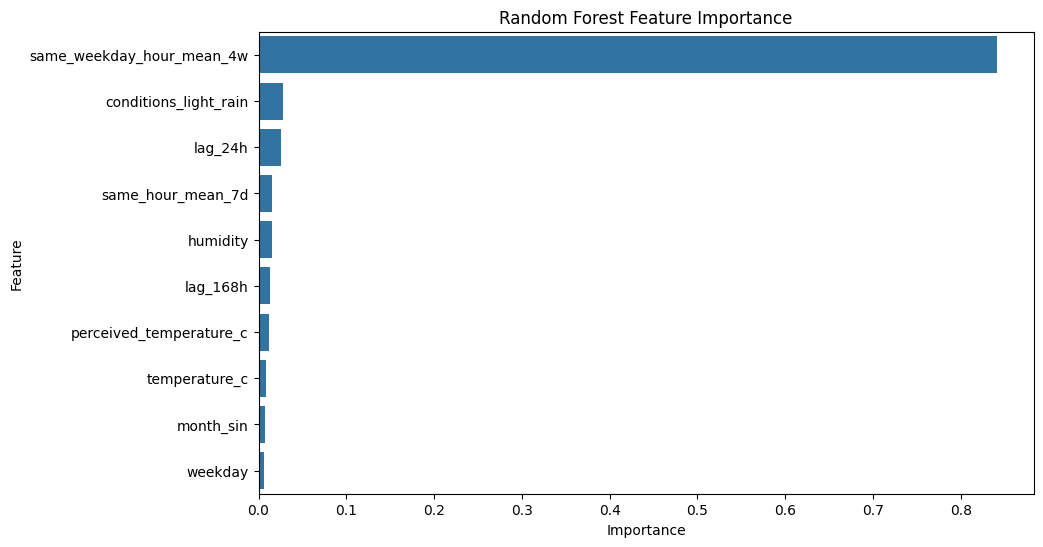

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="importance",
    y="feature",
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

#### Observations

* The `same_weekday_hour_mean_4w` feature is by far the most important predictor in the Random Forest model, accounting for the majority of the model's predictive power.

* The feature importance ranking confirms the findings from the feature engineering experiments, where the introduction of the same weekday-hour historical average produced the largest individual performance improvement.

* The lag features (`lag_24h` and `lag_168h`) remain relevant predictors but contribute substantially less than the contextual historical average.

* Weather-related features such as temperature, perceived temperature, humidity, and precipitation have comparatively small importance values, indicating that they play a secondary role in explaining rental demand.

* The results suggest that recurring temporal behavior is the dominant driver of bike rental demand in this dataset. Historical demand observed under similar temporal conditions appears to be considerably more informative than weather conditions alone.

### Conclusion


The Random Forest model improved upon the best Linear Regression model, increasing the R² score from 0.86 to 0.89. However, the performance gains achieved through feature engineering were substantially larger than those obtained by switching to a more sophisticated model.

These results suggest that identifying informative historical demand features is more important for this forecasting problem than increasing model complexity alone.

The feature importance analysis reinforces the conclusions drawn throughout the modeling process. While weather and calendar information contribute useful context, the strongest predictive signal comes from historical demand patterns. In particular, the average demand observed during the same weekday and hour over previous weeks emerged as the single most informative feature in the dataset.

This finding highlights the highly regular and recurring nature of bike rental demand and explains the substantial performance gains achieved through contextual historical demand features.

## 9. Experiment 5 - XGBoost Regressor

---

### Motivation

The Random Forest model improved upon the best Linear Regression model, suggesting that nonlinear models can capture additional structure in the data.

XGBoost is another tree-based model that often performs well on tabular datasets. Unlike Random Forest, which builds many independent trees, XGBoost builds trees sequentially so that each new tree tries to correct the errors of the previous ones.

This experiment evaluates whether XGBoost can further improve forecasting performance using the best feature set identified so far.

In [27]:
from xgboost import XGBRegressor

In [28]:
xgb_results, xgb_model, xgb_features = run_experiment(
    model=XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
    ),
    X=df[SELECTED_FEATURES],
    y=df[TARGET],
    model_name="XGBoost (Selected Features)",
    return_model=True,
)

experiment_results.append(xgb_results)

xgb_results, xgb_model, xgb_features = run_experiment(
    model=XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
    ),
    X=df[CONTEXTUAL_ROLLING_FEATURES],
    y=df[TARGET],
    model_name="XGBoost (All Features)",
    return_model=True,
)

experiment_results.append(xgb_results)
pd.DataFrame(experiment_results)

,Model,MAE,RMSE,R2
0,Dummy Regressor,174.984601,232.608375,-0.112995
1,Linear Regression (Baseline),134.299475,199.577420,0.180658
2,Linear Regression + Cyclical Features,121.484463,189.591262,0.260600
3,Linear Regression + Lag 24h,78.640753,122.810077,0.690118
4,Linear Regression + Lag 168h,66.953963,103.486786,0.778388
5,Linear Regression + Generic Rolling Means,66.845043,102.597320,0.782181
6,Linear Regression + Same-Hour Mean 7d,66.166453,97.259968,0.804255
7,Linear Regression + Same Weekday-Hour Mean 4w,50.660683,81.246885,0.863469
8,Linear Regression (Selected Features),50.743085,82.735936,0.858419
9,Random Forest (Selected Features),44.922871,72.276789,0.891952


#### Observations

* The XGBoost model achieved the best performance of all evaluated models.

* Compared to the Random Forest model, XGBoost further reduced the MAE from 45.0 to 40.8 rentals and the RMSE from 73.1 to 63.9 rentals.

* The R² score increased from 0.89 to 0.92, indicating that the model is able to explain more than 91% of the variability in bike rental demand.

* The results demonstrate that gradient boosting is able to exploit the engineered features more effectively than both Linear Regression and Random Forest.

* Although model selection contributed additional improvements, the majority of the overall performance gain was achieved through feature engineering rather than the choice of machine learning algorithm.

### Feature Importance Analysis

In [29]:
xgb_feature_importance = pd.DataFrame(
    {
        "feature": xgb_features,
        "importance": xgb_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

xgb_feature_importance

,feature,importance
19,same_weekday_hour_mean_4w,0.589192
18,same_hour_mean_7d,0.088747
9,conditions_light_rain,0.082404
14,lag_24h,0.033925
15,lag_168h,0.023716
6,is_holiday,0.020651
2,humidity,0.019199
12,month_sin,0.017782
1,perceived_temperature_c,0.017260
5,is_weekend,0.015426


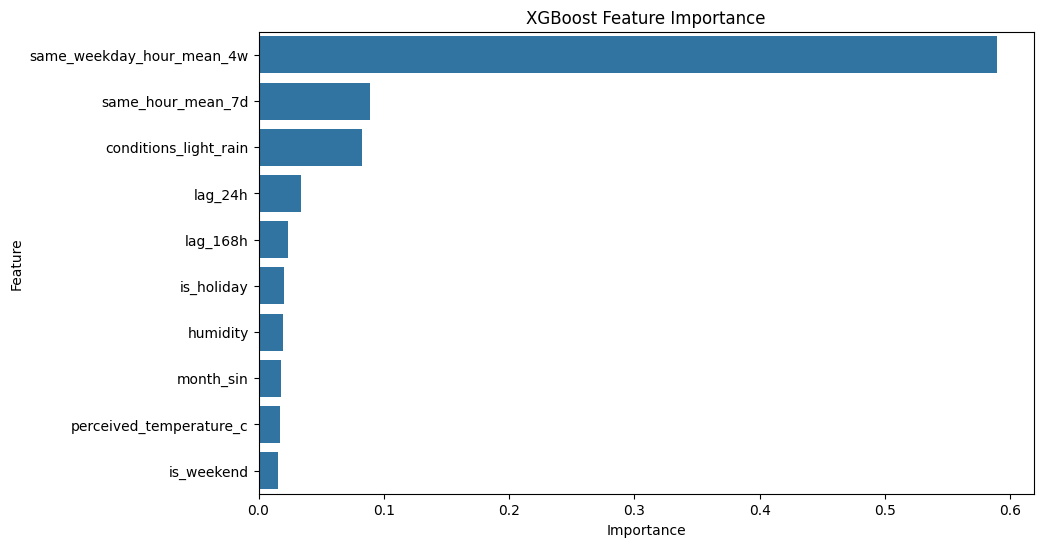

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_feature_importance.head(10),
    x="importance",
    y="feature",
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

#### Observations

* The `same_weekday_hour_mean_4w` feature remains the most important predictor by a substantial margin and contributes nearly half of the total feature importance.

* The weekly lag feature (`lag_168h`) is the second most important predictor, further emphasizing the importance of recurring weekly demand patterns.

* The daily lag feature (`lag_24h`) also contributes significantly, confirming that recent historical demand is one of the strongest drivers of future rental activity.

* Weather-related features such as temperature, humidity, and precipitation contribute useful predictive information but are considerably less important than the historical demand features.

* The cyclical time features (`hour_sin` and `hour_cos`) remain relevant predictors, indicating that daily usage patterns continue to influence demand even after introducing historical demand features.

* Overall, the importance ranking suggests that bike rental demand is primarily driven by recurring temporal behavior, while weather conditions act as secondary influencing factors.

## 10. Model Comparison

---

In [31]:
comparison_models = [
    "Linear Regression (Baseline)",
    "Linear Regression (Selected Features)",
    "Random Forest (Selected Features)",
    "XGBoost (Selected Features)",
]

comparison_df = pd.DataFrame(experiment_results).query("Model in @comparison_models")

comparison_df

,Model,MAE,RMSE,R2
1,Linear Regression (Baseline),134.299475,199.577420,0.180658
8,Linear Regression (Selected Features),50.743085,82.735936,0.858419
9,Random Forest (Selected Features),44.922871,72.276789,0.891952
10,XGBoost (Selected Features),40.166359,62.880688,0.918219


#### Observations

* Feature engineering improved the Linear Regression model from an R² score of 0.18 to 0.86.

* Switching from Linear Regression to Random Forest further increased the R² score to 0.89.

* XGBoost achieved the best overall performance with an R² score above 0.91.

* The largest improvements were obtained through feature engineering rather than model selection.

* Historical demand features proved substantially more valuable than weather-related variables for forecasting rental demand.

## 11. Final Conclusion

This notebook explored multiple feature engineering and modeling approaches for forecasting bike rental demand.

The baseline Linear Regression model achieved an R² score of 0.18 using only weather and calendar information. Successive feature engineering experiments demonstrated that historical demand information is highly predictive and significantly improves forecasting performance.

The most effective features were daily and weekly lag features as well as context-aware historical demand averages, particularly the same weekday-hour historical mean. These features enabled the Linear Regression model to achieve an R² score of approximately 0.86.

Subsequent experiments with Random Forest and XGBoost showed that more sophisticated machine learning models can further improve performance. The best overall result was obtained using XGBoost with the selected feature set, achieving an R² score above 0.91.

Overall, the results indicate that bike rental demand is strongly driven by recurring temporal patterns and historical demand behavior. While model selection contributed additional improvements, the majority of the performance gains were achieved through feature engineering and the incorporation of historical demand information.

The selected XGBoost model and feature set provide a strong foundation for future integration into the production pipeline.

### Future Improvements

Future work could explore modeling booked rentals and direct pickups separately before combining the predictions into a total rental forecast.